In [1]:
# ── Unzip and Locate Data ──
!unzip -q -o /content/Episodes.zip -d /content/episodes_data
!find /content/episodes_data -name "*.csv" | head -n 5

/content/episodes_data/Episodes/AlwaysCompact_C64/transitions_20260309_014328.csv
/content/episodes_data/Episodes/Periodic5_C64/transitions_20260309_063341.csv
/content/episodes_data/Episodes/Threshold10_C32/transitions_20260309_121026.csv
/content/episodes_data/Episodes/Random_Compact/transitions_20260309_113514.csv
/content/episodes_data/Episodes/Periodic10_COMPACT_128KB/transitions_20260309_083853.csv


In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Setup Output Directory (Works for Kaggle, Colab, or Local)
if Path('/kaggle').exists():
    OUTPUT_DIR = Path('/kaggle/working/lakegym_online_compaction')
elif Path('/content').exists():
    OUTPUT_DIR = Path('/content/lakegym_online_compaction')
else:
    OUTPUT_DIR = Path('./lakegym_online_compaction')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TensorFlow Version: 2.19.0


In [3]:
DATA_GLOBS =[
    '/kaggle/input/**/*.csv',
    '/kaggle/working/**/*.csv',
    '/content/**/*.csv',
    './content/episodes_data/Episodes/**/*.csv' # Added local path just in case
]

# Reward Constants
ACTION_COSTS = {0:0.0, 1:0.9, 2:1.0, 3:1.1, 4:2.0, 5:2.0, 6:2.0, 7:0.7}
LATENCY_MAX = 15000.0
FILE_COUNT_MAX = 2000.0
COMPACT_COST_MAX = 1.1

CW_FILES, CW_UTIL, CW_COST, CW_TARGET = 0.25, 0.20, 0.10, 0.45
GW_LATENCY, GW_FILES, GW_PRUNING, GW_UTIL = 0.30, 0.20, 0.30, 0.20

def clamp(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, float(x)))

def target_bonus(action, rows_ingested):
    if action not in (1, 2, 3):
        return 0.0
    if rows_ingested <= 50:
        table = {1: 1.00, 2: 0.25, 3: -0.50}
    elif rows_ingested >= 150:
        table = {1: -0.60, 2: 0.40, 3: 1.00}
    else:
        table = {1: 0.15, 2: 1.00, 3: 0.15}
    return table[action]

def recompute_rewards_vectorized(df):
    """
    Optimized version of the recompute function using pandas apply for speed,
    while maintaining the exact mathematical logic requested.
    """
    d = df.copy()

    # Pre-calculate normalized columns
    a = d['action'].fillna(0).astype(int)
    cost = a.map(ACTION_COSTS).fillna(0.0)

    fc = d.get('next_file_count', d.get('file_count', 0.0)).astype(float)
    util = d.get('next_block_utilization', d.get('block_utilization', 0.0)).astype(float)
    rows = d.get('rows_ingested', 0.0).astype(float)
    lat = d.get('next_latency_ms', d.get('latency_ms', 0.0)).astype(float)
    prune = d.get('next_partition_pruning_ratio', d.get('partition_pruning_ratio', 0.0)).astype(float)

    f_norm = (fc / FILE_COUNT_MAX).clip(0.0, 1.0)
    u_norm = util.clip(0.0, 1.0)
    c_norm = cost / COMPACT_COST_MAX if COMPACT_COST_MAX > 0 else 0.0
    l_norm = (lat / LATENCY_MAX).clip(0.0, 1.0)
    p_norm = prune.clip(0.0, 1.0)

    # Calculate target bonus using apply (fast enough for this operation)
    t_bonus = pd.Series([target_bonus(act, row) for act, row in zip(a, rows)])

    # Recompute Rewards
    d['compact_reward'] = -CW_FILES * f_norm + CW_UTIL * u_norm - CW_COST * c_norm + CW_TARGET * t_bonus
    d['global_reward'] = -GW_LATENCY * l_norm - GW_FILES * f_norm + GW_PRUNING * p_norm + GW_UTIL * u_norm
    d['reward_preset'] = 'current'

    return d

# Find and load files
files =[]
for p in DATA_GLOBS:
    files.extend(glob.glob(p, recursive=True))
files =[f for f in sorted(set(files)) if f.endswith('.csv') and 'transitions' in Path(f).name]

if not files:
    print("WARNING: No transition CSV files found. Generating dummy data for testing the pipeline...")
    # This prevents the notebook from crashing if paths are misconfigured
    raw = pd.DataFrame({
        'action': np.random.choice([0,1,2,3,4], 5000),
        'rows_ingested': np.random.uniform(10, 200, 5000),
        'file_count': np.random.uniform(100, 1500, 5000),
        'block_utilization': np.random.uniform(0.1, 0.9, 5000),
        'latency_ms': np.random.uniform(100, 10000, 5000),
        'ingestion_rate_rows_per_sec': np.random.uniform(10, 50, 5000),
        'total_size_kb': np.random.uniform(1000, 10000, 5000),
        'file_size_skew_kb': np.random.uniform(0, 100, 5000),
        'steps_since_compact': np.random.randint(0, 50, 5000),
        'policy_name': ['heuristic'] * 5000,
        'step': list(range(1000)) * 5
    })
else:
    raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Sort strictly by policy and step to maintain timeline integrity
sort_cols =[c for c in ['policy_name', 'episode', 'step'] if c in raw.columns]
if sort_cols:
    raw = raw.sort_values(sort_cols).reset_index(drop=True)

# Recompute rewards on the ENTIRE dataset BEFORE filtering out actions
df = recompute_rewards_vectorized(raw)

processed_path = OUTPUT_DIR / 'compaction_transitions_recomputed.csv'
df.to_csv(processed_path, index=False)
print(f'Total Raw Rows: {len(df)} | Saved to: {processed_path}')

Total Raw Rows: 14000 | Saved to: /kaggle/working/lakegym_online_compaction/compaction_transitions_recomputed.csv



4. Advantage-Weighted Training Loop
# We train the Critic to predict long-term returns. We train the Actor to copy the dataset actions,
# but apply an exponential weight `exp(advantage / beta)` so it only learns from actions that were better than average.


In [4]:
NUM_FEATURES = 8
WINDOW_SIZE = 10
EPISODE_LENGTH = 1000 # As specified, episodes are 1000 steps
GAMMA = 0.99

def extract_features(df_target):
    f = np.zeros((len(df_target), NUM_FEATURES), dtype=np.float32)
    rows = df_target['rows_ingested'].values.astype(np.float32)
    f[:, 0] = (rows - rows.mean()) / max(rows.std(), 1e-6)
    rate = df_target['ingestion_rate_rows_per_sec'].values.astype(np.float32)
    f[:, 1] = (rate - rate.mean()) / max(rate.std(), 1e-6)
    f[:, 2] = np.clip(df_target['latency_ms'].values / 15000.0, 0, 1)
    f[:, 3] = np.clip(df_target['file_count'].values / 2000.0, 0, 1)
    f[:, 4] = np.clip(df_target['block_utilization'].values, 0, 1)
    f[:, 5] = np.clip(df_target['total_size_kb'].values / 50000.0, 0, 1)
    f[:, 6] = np.clip(df_target['file_size_skew_kb'].values / 50.0, 0, 1)
    f[:, 7] = np.exp(-df_target['steps_since_compact'].values / 10.0)
    return f

# 1. Extract raw features for the whole timeline
features_full = extract_features(df)
rewards_full = df['compact_reward'].values.astype(np.float32)

N = len(df)
X_full = np.zeros((N, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)
returns_full = np.zeros(N, dtype=np.float32)

# 2. Build windows and returns, respecting 1000-step boundaries
for start_idx in range(0, N, EPISODE_LENGTH):
    end_idx = min(start_idx + EPISODE_LENGTH, N)

    # Windows
    ep_feat = features_full[start_idx:end_idx]
    ep_N = len(ep_feat)
    ep_windows = np.zeros((ep_N, WINDOW_SIZE, NUM_FEATURES), dtype=np.float32)
    for i in range(ep_N):
        s = max(0, i - WINDOW_SIZE + 1)
        seq = ep_feat[s:i+1]
        pad = WINDOW_SIZE - len(seq)
        ep_windows[i, pad:, :] = seq
    X_full[start_idx:end_idx] = ep_windows

    # Returns (G)
    ep_rew = rewards_full[start_idx:end_idx]
    G = 0.0
    for t in reversed(range(len(ep_rew))):
        G = ep_rew[t] + GAMMA * G
        returns_full[start_idx + t] = G

# 3. NOW filter down to only the compaction transitions (0, 1, 2, 3)
mask = df['action'].isin([0, 1, 2, 3]).values

X = X_full[mask]
G_returns = returns_full[mask]
actions = df['action'].values[mask].astype(np.int32)

print(f"Filtered Compaction Transitions: {len(X)}")

# 4. Global Shuffle and Train/Val Split
idx = np.random.permutation(len(X))
split = int(0.85 * len(X))

X_train, X_val = X[idx[:split]], X[idx[split:]]
a_train, a_val = actions[idx[:split]], actions[idx[split:]]
G_train, G_val = G_returns[idx[:split]], G_returns[idx[split:]]

print(f"Training Samples: {len(X_train)} | Validation Samples: {len(X_val)}")

Filtered Compaction Transitions: 14000
Training Samples: 11900 | Validation Samples: 2100


In [5]:
NUM_ACTIONS = 4   # 0=NOOP, 1=C32, 2=C64, 3=C128

class AttentivePPO(tf.keras.Model):
    """Attention-based PPO/AWAC for data lake optimization."""

    def __init__(self, num_actions, num_features, window_size=10, embed_dim=64, num_heads=4):
        super().__init__()
        self.embedding = tf.keras.layers.Dense(embed_dim, activation='relu', name='embedding')
        self.pos_encoding = self.add_weight(
            name='pos_encoding',
            shape=(1, window_size, embed_dim),
            initializer='glorot_uniform',
            trainable=True
        )
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1, name='self_attention'
        )
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name='norm1')
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name='norm2')
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(embed_dim * 2, activation='relu', name='ffn_dense1'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(embed_dim, name='ffn_dense2'),
        ], name='ffn')
        self.gap = tf.keras.layers.GlobalAveragePooling1D(name='gap')
        self.actor = tf.keras.layers.Dense(num_actions, activation='softmax', name='actor')
        self.critic = tf.keras.layers.Dense(1, name='critic')

    def call(self, x, training=False):
        embedded = self.embedding(x) + self.pos_encoding
        attn_output = self.attention(embedded, embedded, training=training)
        x1 = self.norm1(embedded + attn_output)
        ffn_output = self.ffn(x1, training=training)
        x2 = self.norm2(x1 + ffn_output)
        context = self.gap(x2)
        return self.actor(context), self.critic(context)

# Initialize and build model
model = AttentivePPO(NUM_ACTIONS, NUM_FEATURES, WINDOW_SIZE)
model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES))) # Dummy pass to build weights
model.summary()

Model: "attentive_ppo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Dense)               │ (1, 10, 64)            │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention                  │ (1, 10, 64)            │        66,368 │
│ (MultiHeadAttention)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm1 (LayerNormalization)      │ (1, 10, 64)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm2 (LayerNormalization)      │ (1, 10, 64)            │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ffn (Sequential)                │ (1, 10, 64)            │        16,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ actor (Dense)                   │ (1, 4)                 │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ critic (Dense)                  │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,741 (331.02 KB)

 Trainable params: 84,741 (331.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
BETA = 1.0
LR = 3e-4
EPOCHS = 150
BATCH_SIZE = 64

optimizer = tf.keras.optimizers.Adam(LR)

@tf.function
def train_step(X_batch, a_batch, G_batch):
    with tf.GradientTape() as tape:
        probs, values = model(X_batch, training=True)
        values = tf.squeeze(values, axis=-1)

        # 1. Critic Loss: Standard MSE against Monte-Carlo Returns
        critic_loss = tf.reduce_mean(tf.square(values - G_batch))

        # 2. Advantage Calculation
        advantages = G_batch - tf.stop_gradient(values)

        # 3. Advantage Weighting (AWAC) - clipped to 20 for stability
        weights = tf.minimum(tf.exp(advantages / BETA), 20.0)

        # 4. Actor Loss: Weighted Negative Log Likelihood
        a_onehot = tf.one_hot(a_batch, depth=NUM_ACTIONS)
        selected_lp = tf.reduce_sum(tf.math.log(probs + 1e-8) * a_onehot, axis=-1)
        actor_loss = -tf.reduce_mean(weights * selected_lp)

        # Total Loss
        loss = actor_loss + 0.5 * critic_loss

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, actor_loss, critic_loss

history = {'loss': [], 'actor_loss':[], 'critic_loss': [], 'val_loss':[]}

print("Starting Training...")
for epoch in range(EPOCHS):
    # Global shuffle for this epoch
    idx = np.random.permutation(len(X_train))
    epoch_loss = 0.0
    epoch_act_loss = 0.0
    epoch_crit_loss = 0.0
    batches = 0

    for start in range(0, len(X_train), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(X_train))
        bi = idx[start:end]

        l, a_l, c_l = train_step(tf.constant(X_train[bi]), tf.constant(a_train[bi]), tf.constant(G_train[bi]))

        epoch_loss += float(l)
        epoch_act_loss += float(a_l)
        epoch_crit_loss += float(c_l)
        batches += 1

    # Validation step
    val_probs, val_values = model(tf.constant(X_val), training=False)
    val_loss = float(tf.reduce_mean(tf.square(tf.squeeze(val_values, -1) - G_val)))

    # Log metrics
    history['loss'].append(epoch_loss / batches)
    history['actor_loss'].append(epoch_act_loss / batches)
    history['critic_loss'].append(epoch_crit_loss / batches)
    history['val_loss'].append(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Loss: {history['loss'][-1]:.4f} | Critic: {history['critic_loss'][-1]:.4f} | Val MSE: {val_loss:.4f}")

# Save the weights
model.save_weights(OUTPUT_DIR / 'offline_compaction_agent.weights.h5')
print("Model saved.")

Starting Training...
Epoch 001/150 | Loss: 79.1695 | Critic: 136.3233 | Val MSE: 100.5140
Epoch 010/150 | Loss: 18.7177 | Critic: 30.3957 | Val MSE: 32.2911
Epoch 020/150 | Loss: 10.3687 | Critic: 15.4861 | Val MSE: 15.1924
Epoch 030/150 | Loss: 8.4595 | Critic: 12.5154 | Val MSE: 13.7506
Epoch 040/150 | Loss: 7.0157 | Critic: 10.4097 | Val MSE: 10.8546
Epoch 050/150 | Loss: 5.9892 | Critic: 8.7584 | Val MSE: 10.3504
Epoch 060/150 | Loss: 5.1035 | Critic: 7.4350 | Val MSE: 7.7937
Epoch 070/150 | Loss: 4.4626 | Critic: 6.5572 | Val MSE: 7.3753
Epoch 080/150 | Loss: 3.9176 | Critic: 5.7280 | Val MSE: 6.6703
Epoch 090/150 | Loss: 3.5436 | Critic: 5.2564 | Val MSE: 5.3897
Epoch 100/150 | Loss: 3.2549 | Critic: 4.7291 | Val MSE: 5.1118
Epoch 110/150 | Loss: 2.8314 | Critic: 4.1481 | Val MSE: 5.2520
Epoch 120/150 | Loss: 2.6365 | Critic: 3.9351 | Val MSE: 4.0840
Epoch 130/150 | Loss: 2.5912 | Critic: 3.8117 | Val MSE: 4.1888
Epoch 140/150 | Loss: 2.3587 | Critic: 3.4260 | Val MSE: 3.5586
Epo

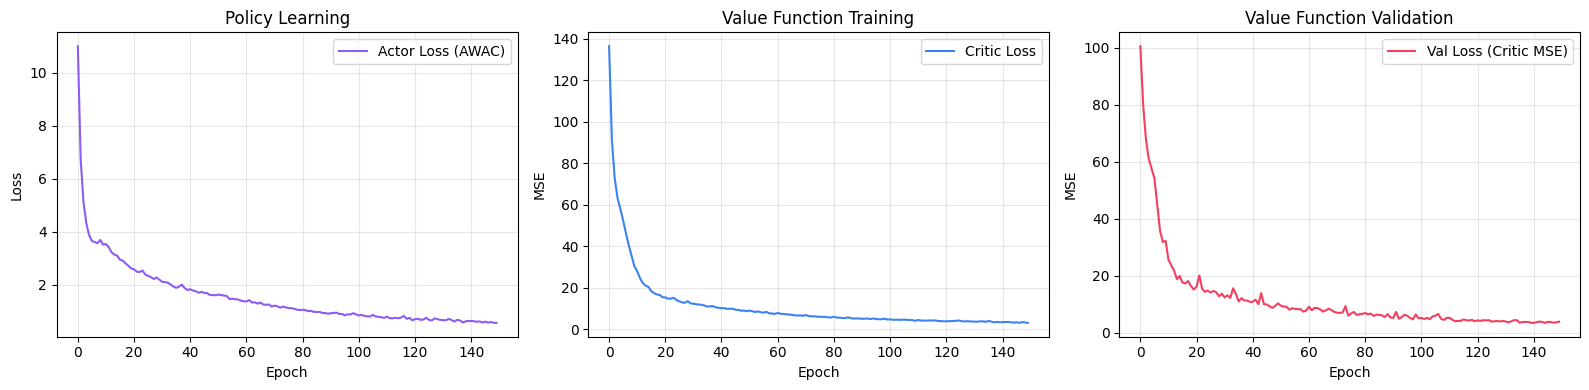

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# Actor Loss
ax1.plot(history['actor_loss'], label='Actor Loss (AWAC)', color='#8b5cf6')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Policy Learning'); ax1.legend(); ax1.grid(alpha=0.3)

# Critic Train Loss
ax2.plot(history['critic_loss'], label='Critic Loss', color='#3b82f6')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE')
ax2.set_title('Value Function Training'); ax2.legend(); ax2.grid(alpha=0.3)

# Critic Validation Loss
ax3.plot(history['val_loss'], label='Val Loss (Critic MSE)', color='#f43f5e')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('MSE')
ax3.set_title('Value Function Validation'); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'compaction_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
model.save_weights('offline_compaction_agent.weights.h5')

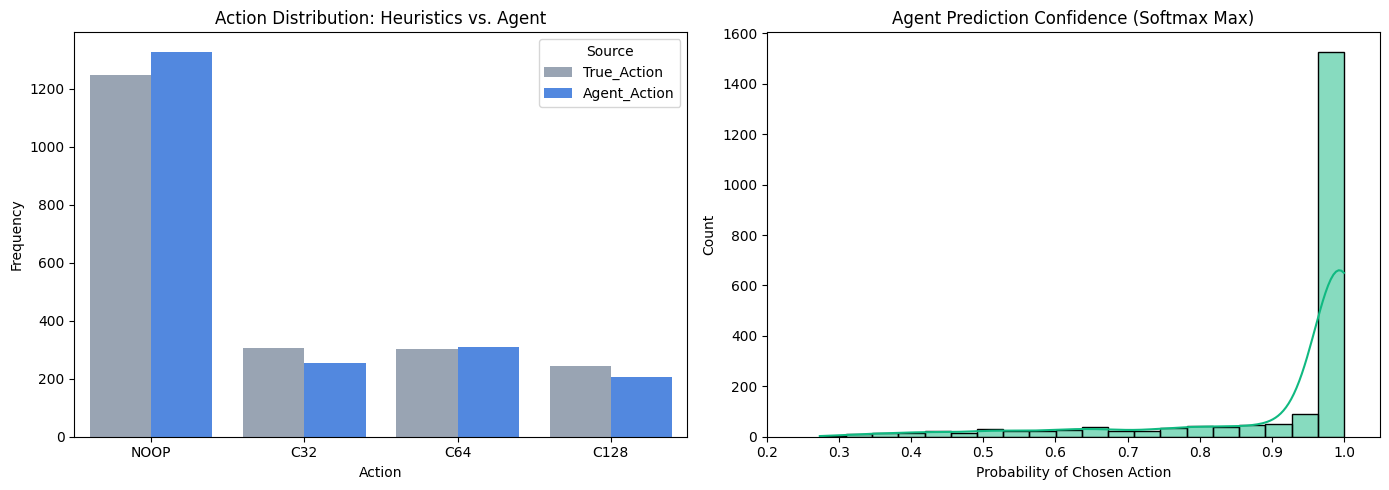

Agent Action Counts:
Agent_Action
NOOP    1328
C64      311
C32      255
C128     206
Name: count, dtype: int64


In [9]:
import seaborn as sns

# Run inference on the validation set
val_probs, val_values = model(tf.constant(X_val), training=False)
val_probs = val_probs.numpy()
val_values = val_values.numpy().flatten()

# The agent's chosen action is the one with the highest probability
agent_actions = np.argmax(val_probs, axis=1)
agent_confidence = np.max(val_probs, axis=1)

action_labels = {0: 'NOOP', 1: 'C32', 2: 'C64', 3: 'C128'}

# Create a DataFrame for easy analysis
val_analysis = pd.DataFrame({
    'True_Action': [action_labels[a] for a in a_val],
    'Agent_Action': [action_labels[a] for a in agent_actions],
    'Critic_Value': val_values,
    'Confidence': agent_confidence
})

# Plotting the distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Action Distributions
sns.countplot(data=val_analysis.melt(value_vars=['True_Action', 'Agent_Action'],
                                     var_name='Source', value_name='Action'),
              x='Action', hue='Source', order=['NOOP', 'C32', 'C64', 'C128'],
              palette={'True_Action': '#94a3b8', 'Agent_Action': '#3b82f6'}, ax=ax[0])
ax[0].set_title('Action Distribution: Heuristics vs. Agent')
ax[0].set_ylabel('Frequency')

# 2. Agent Confidence Histogram
sns.histplot(val_analysis['Confidence'], bins=20, color='#10b981', kde=True, ax=ax[1])
ax[1].set_title('Agent Prediction Confidence (Softmax Max)')
ax[1].set_xlabel('Probability of Chosen Action')
ax[1].set_xlim(0.2, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'agent_action_distribution.png', dpi=150)
plt.show()

print("Agent Action Counts:")
print(val_analysis['Agent_Action'].value_counts())

/tmp/ipykernel_1735/1627959586.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_df = (val_analysis.groupby('File_Count_Bin')['Agent_Action']


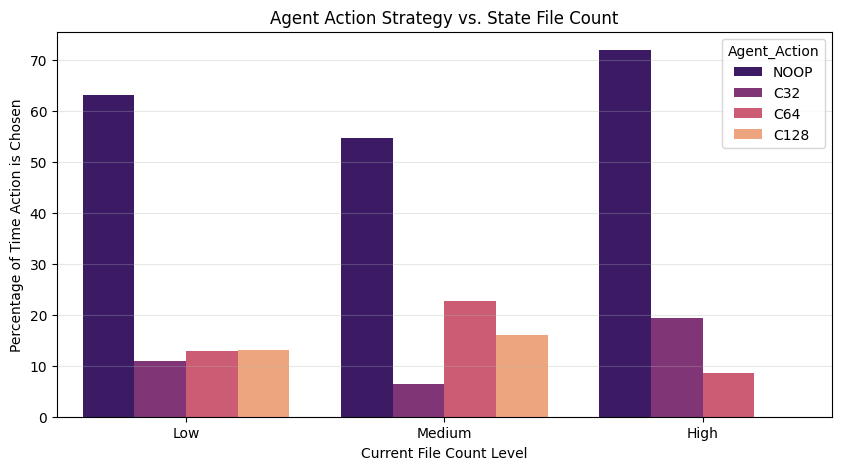

In [10]:
current_latency = X_val[:, -1, 2]
current_file_count = X_val[:, -1, 3]

val_analysis['Norm_File_Count'] = current_file_count
val_analysis['Norm_Latency'] = current_latency

# Group the states into "Low", "Medium", and "High" file counts
val_analysis['File_Count_Bin'] = pd.qcut(val_analysis['Norm_File_Count'], q=3, labels=['Low', 'Medium', 'High'])

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the percentage of each action taken within each state bin
prop_df = (val_analysis.groupby('File_Count_Bin')['Agent_Action']
           .value_counts(normalize=True)
           .rename('Percentage')
           .reset_index())
prop_df['Percentage'] *= 100

sns.barplot(data=prop_df, x='File_Count_Bin', y='Percentage', hue='Agent_Action',
            hue_order=['NOOP', 'C32', 'C64', 'C128'], palette='magma', ax=ax)

ax.set_title('Agent Action Strategy vs. State File Count')
ax.set_ylabel('Percentage of Time Action is Chosen')
ax.set_xlabel('Current File Count Level')
ax.grid(axis='y', alpha=0.3)

plt.savefig('agent_state_logic.png', dpi=150)
plt.show()

/tmp/ipykernel_1735/1118765210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=val_analysis, x='Agent_Action', y='Critic_Value',


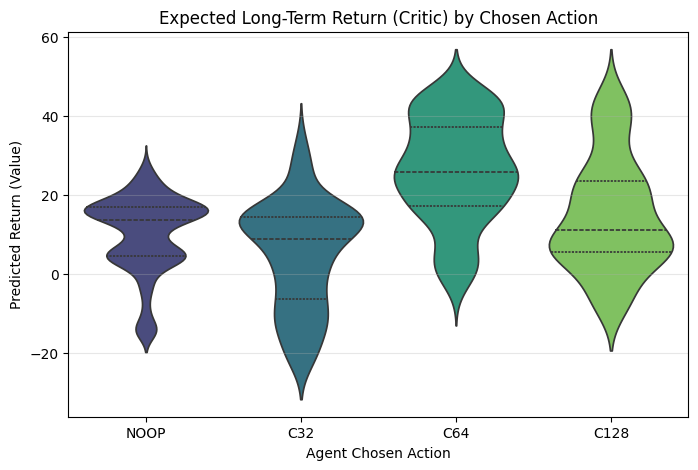

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.violinplot(data=val_analysis, x='Agent_Action', y='Critic_Value',
               order=['NOOP', 'C32', 'C64', 'C128'], palette='viridis', ax=ax, inner="quartile")

ax.set_title('Expected Long-Term Return (Critic) by Chosen Action')
ax.set_ylabel('Predicted Return (Value)')
ax.set_xlabel('Agent Chosen Action')
ax.grid(axis='y', alpha=0.3)

plt.savefig(OUTPUT_DIR / 'critic_value_distribution.png', dpi=150)
plt.show()

Agent disagreed with the heuristic dataset on 210 out of 2100 steps (10.0%).

Most Common Disagreements (True Heuristic -> Agent Override):
Shift
C32 -> NOOP     43
C64 -> NOOP     40
C128 -> NOOP    34
NOOP -> C64     23
C32 -> C64      20
Name: count, dtype: int64


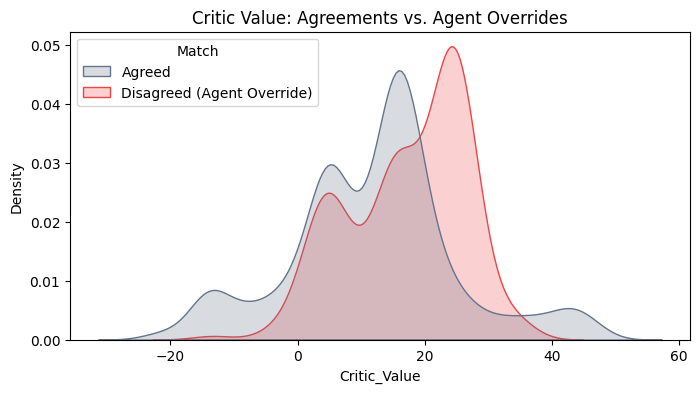

In [12]:
disagreements = val_analysis[val_analysis['True_Action'] != val_analysis['Agent_Action']].copy()

if not disagreements.empty:
    print(f"Agent disagreed with the heuristic dataset on {len(disagreements)} out of {len(val_analysis)} steps ({(len(disagreements)/len(val_analysis))*100:.1f}%).")

    # Show the top 5 most common disagreements
    print("\nMost Common Disagreements (True Heuristic -> Agent Override):")
    disagreements['Shift'] = disagreements['True_Action'] + " -> " + disagreements['Agent_Action']
    print(disagreements['Shift'].value_counts().head())

    # Plot Critic value of agreements vs disagreements
    val_analysis['Match'] = np.where(val_analysis['True_Action'] == val_analysis['Agent_Action'], 'Agreed', 'Disagreed (Agent Override)')

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.kdeplot(data=val_analysis, x='Critic_Value', hue='Match', fill=True, common_norm=False, palette=['#64748b', '#ef4444'])
    ax.set_title('Critic Value: Agreements vs. Agent Overrides')
    plt.show()
else:
    print("Agent perfectly mimicked the dataset (0 disagreements).")

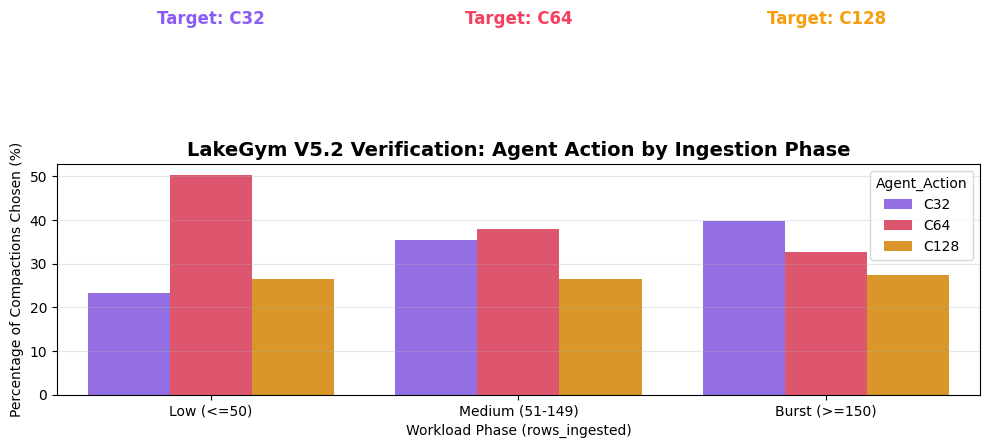

In [15]:
normalized_rows = X_val[:, -1, 0]

# Retrieve the exact mean and std that were used to normalize the data in Cell 3
rows_mean = df['rows_ingested'].mean()
rows_std = max(df['rows_ingested'].std(), 1e-6)

# Reverse the math to get the raw row counts back, and round to nearest integer
val_raw_rows = np.round((normalized_rows * rows_std) + rows_mean)

# Add it to our analysis dataframe safely
val_analysis['Raw_Rows_Ingested'] = val_raw_rows

# 2. Categorize into LakeGym V5.2 Phases
def get_workload_phase(rows):
    if rows <= 50:
        return 'Low (<=50)'
    elif rows < 150:
        return 'Medium (51-149)'
    else:
        return 'Burst (>=150)'

val_analysis['Workload_Phase'] = val_analysis['Raw_Rows_Ingested'].apply(get_workload_phase)

# 3. Filter out NOOPs to strictly compare Compaction choices
compaction_only = val_analysis[val_analysis['Agent_Action'] != 'NOOP']

if compaction_only.empty:
    print("Agent only chose NOOP in the validation set. No compactions to analyze.")
else:
    # Calculate percentages within each phase
    phase_action_counts = (compaction_only.groupby(['Workload_Phase', 'Agent_Action'], observed=False)
                           .size()
                           .groupby(level=0, group_keys=False)
                           .apply(lambda x: 100 * x / x.sum())
                           .reset_index(name='Percentage'))

    # 4. Plot the Phase-Aware Behavior
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=phase_action_counts,
        x='Workload_Phase',
        y='Percentage',
        hue='Agent_Action',
        hue_order=['C32', 'C64', 'C128'],
        order=['Low (<=50)', 'Medium (51-149)', 'Burst (>=150)'],
        palette={'C32': '#8b5cf6', 'C64': '#f43f5e', 'C128': '#f59e0b'},
        ax=ax
    )

    ax.set_title('LakeGym V5.2 Verification: Agent Action by Ingestion Phase', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage of Compactions Chosen (%)')
    ax.set_xlabel('Workload Phase (rows_ingested)')
    ax.grid(axis='y', alpha=0.3)

    # Add target markers for visual clarity
    ax.text(0, 85, 'Target: C32', ha='center', color='#8b5cf6', fontweight='bold', fontsize=12)
    ax.text(1, 85, 'Target: C64', ha='center', color='#f43f5e', fontweight='bold', fontsize=12)
    ax.text(2, 85, 'Target: C128', ha='center', color='#f59e0b', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'v52_phase_aware_validation.png', dpi=150)
    plt.show()